In [1]:
# Load Customs 2015 dataset
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Lance Santos\Downloads\Data Folder\bettergov.ph 2015.csv",
    encoding="cp1252"
)

print(df.shape)
print(df.columns.tolist())

C:\Users\Lance Santos\AppData\Local\Temp\ipykernel_28232\1211923022.py:4: DtypeWarning: Columns (4: entry, 25: prefcode, 28: subport, 29: port) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(2236612, 30)
['uid', 'ty', 'tq', 'tm', 'entry', 'hscode', 'goodsdescription', 'p', 'q', 'm_fob', 'm_cif', 'fx_usd', 'dutiablevalueforeign', 'exchangerate', 'currency', 'dutiablevaluephp', 'dutypaid', 'exciseadvalorem', 'arrastre', 'wharfage', 'vatbase', 'vatpaid', 'othertax', 'finesandpenalties', 'dutiestaxes', 'prefcode', 'countryorigin_iso3', 'countryexport_iso3', 'subport', 'port']


In [2]:
print(df["dutiablevaluephp"].dtype)
print(df["dutiablevaluephp"].describe())
print(df["dutiablevaluephp"].isna().sum())

int64
count    2.236612e+06
mean     1.603885e+06
std      2.479364e+07
min      1.000000e+00
25%      1.901500e+04
50%      1.016945e+05
75%      5.849100e+05
max      8.367496e+09
Name: dutiablevaluephp, dtype: float64
0


In [3]:
#convert to a NumPy array
import numpy as np

values = df["dutiablevaluephp"].dropna().to_numpy()

print(type(values))
print(values.shape)

<class 'numpy.ndarray'>
(2236612,)


In [4]:
#boolean mask + aggregation
threshold = 1000000

mask = values > threshold

filtered_values = values[mask]

print("Number above threshold:", len(filtered_values))
print("Total:", np.sum(filtered_values))



Number above threshold: 411305
Total: 3288821943420


In [5]:
#fixed seed sample
rng = np.random.default_rng(42)

sample = rng.choice(values, size=10000, replace=False)
print(sample.shape)

(10000,)


In [6]:
#vectorized calculation / calculates 10% of each value in the sample at once using numpy

vectorized_result = sample* 0.10 
print(vectorized_result[:5])

[10328.6 28277.1  5562.4  4929.4  3778. ]


In [7]:
#same calculation with a loop

loop_result = []
for value in sample:
    loop_result.append(value * 0.10)

loop_result = np.array(loop_result)

print(loop_result[:5])

[10328.6 28277.1  5562.4  4929.4  3778. ]


In [8]:
#verify equal results
print(np.allclose(vectorized_result, loop_result))

True


In [9]:
#benchmark 5 runs
import time

loop_times = []
vectorized_times = []

for _ in range(5):
    # Time loop calculation
    start = time.perf_counter()

    result = []
    for value in sample:
        result.append(value * 0.10)

    result = np.array(result)

    end = time.perf_counter()
    loop_times.append(end - start)

    # Time vectorized calculation
    start = time.perf_counter()

    result = sample * 0.10

    end = time.perf_counter()
    vectorized_times.append(end - start)

print("Loop times:", loop_times)
print("Vectorized times:", vectorized_times)

print("Loop median:", np.median(loop_times))
print("Vectorized median:", np.median(vectorized_times))

Loop times: [0.01838889998907689, 0.02207069999712985, 0.01678429999446962, 0.017246999996132217, 0.01795789999596309]
Vectorized times: [0.00031119999766815454, 0.00022509999689646065, 2.3999993572942913e-05, 3.9399994420818985e-05, 0.00013719999697059393]
Loop median: 0.01795789999596309
Vectorized median: 0.00013719999697059393


In [10]:
from src.numpy_ops import (
    apply_mask,
    vectorized_calculation,
    loop_calculation,
    aggregate_values
)

In [11]:
filtered_values = apply_mask(values, 1_000_000)

print("Number above threshold:", len(filtered_values))
print("Total:", aggregate_values(filtered_values))

Number above threshold: 411305
Total: 3288821943420.0


In [12]:
vectorized_result = vectorized_calculation(sample)
loop_result = loop_calculation(sample)

print(np.allclose(vectorized_result, loop_result))

True


In [13]:
import pandas as pd

top10 = pd.read_csv("top10.csv")
pivot = pd.read_csv("pivot.csv")

print("TOP10 shape:", top10.shape)
print("TOP10 columns:", top10.columns.tolist())

print("\nPIVOT shape:", pivot.shape)
print("PIVOT columns:", pivot.columns.tolist())

TOP10 shape: (10, 5)
TOP10 columns: ['countryorigin_iso3', 'row_count', 'valid_count', 'sum', 'mean']

PIVOT shape: (198, 6)
PIVOT columns: ['countryorigin_iso3', '2015q1', '2015q2', '2015q3', '2015q4', 'Total']


In [14]:
from src.plots import make_bar_plot, make_heatmap

In [15]:
make_bar_plot(
    data=top10,
    x_column="countryorigin_iso3",
    y_column="sum",
    title="Top 10 Countries by Dutiable Value",
    x_label="Country of Origin (ISO3)",
    y_label="Dutiable Value (PHP)",
    output_path="bar.png",
)

In [16]:
import inspect
print("set_yticks([])" in inspect.getsource(make_heatmap))

False


This shows the top 10 countries by total dutiable value in the Customs 2015 Summary

In [17]:
heatmap_data = pivot.set_index("countryorigin_iso3")[
    ["2015q1", "2015q2", "2015q3", "2015q4"]
].drop(index="Total")

In [18]:
import os
from datetime import datetime

path = r"C:\Users\Lance Santos\Downloads\case-study-2-git\heatmap.png"

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path), "bytes")
print("Modified:", datetime.fromtimestamp(os.path.getmtime(path)))

Exists: True
Size: 454337 bytes
Modified: 2026-09-24 19:41:38.478910


In [19]:
import src.plots

print(src.plots.__file__)

c:\Users\Lance Santos\Downloads\case-study-2-git\src\plots.py


In [20]:
make_heatmap(
    data=heatmap_data,
    title="Dutiable Value by Country of Origin and Quarter",
    x_label="Quarter",
    y_label="Country of Origin (ISO3)",
    output_path="heatmap.png"
)

197 labels for 197 rows


In [22]:
import inspect
print(inspect.getsource(make_heatmap))

def make_heatmap(
    data: pd.DataFrame,
    title: str,
    x_label: str,
    y_label: str,
    output_path: str,
) -> None:
    """Create and save a Seaborn heatmap."""
    plt.figure(figsize=(12, 40))

    vmax = data.stack().quantile(0.99)

    ax = sns.heatmap(
        data,
        cmap="YlOrRd",
        linewidths=0.2,
        linecolor="white",
        vmin=0,
        vmax=vmax,
        yticklabels=True,
        xticklabels=True,
        cbar_kws={"label": "Dutiable Value (PHP)"},
    )

    ax.tick_params(axis="y", labelsize=6)
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    print(len(ax.get_yticklabels()), "labels for", len(data), "rows")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()



In [25]:
print(heatmap_data.index[30:37].tolist())
print(heatmap_data.index.dtype)
print(heatmap_data.index.is_unique)

['CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COL']
str
True


Number of rows: 197
Number of tick positions: 197
Number of tick labels: 197
CHN label exists: True


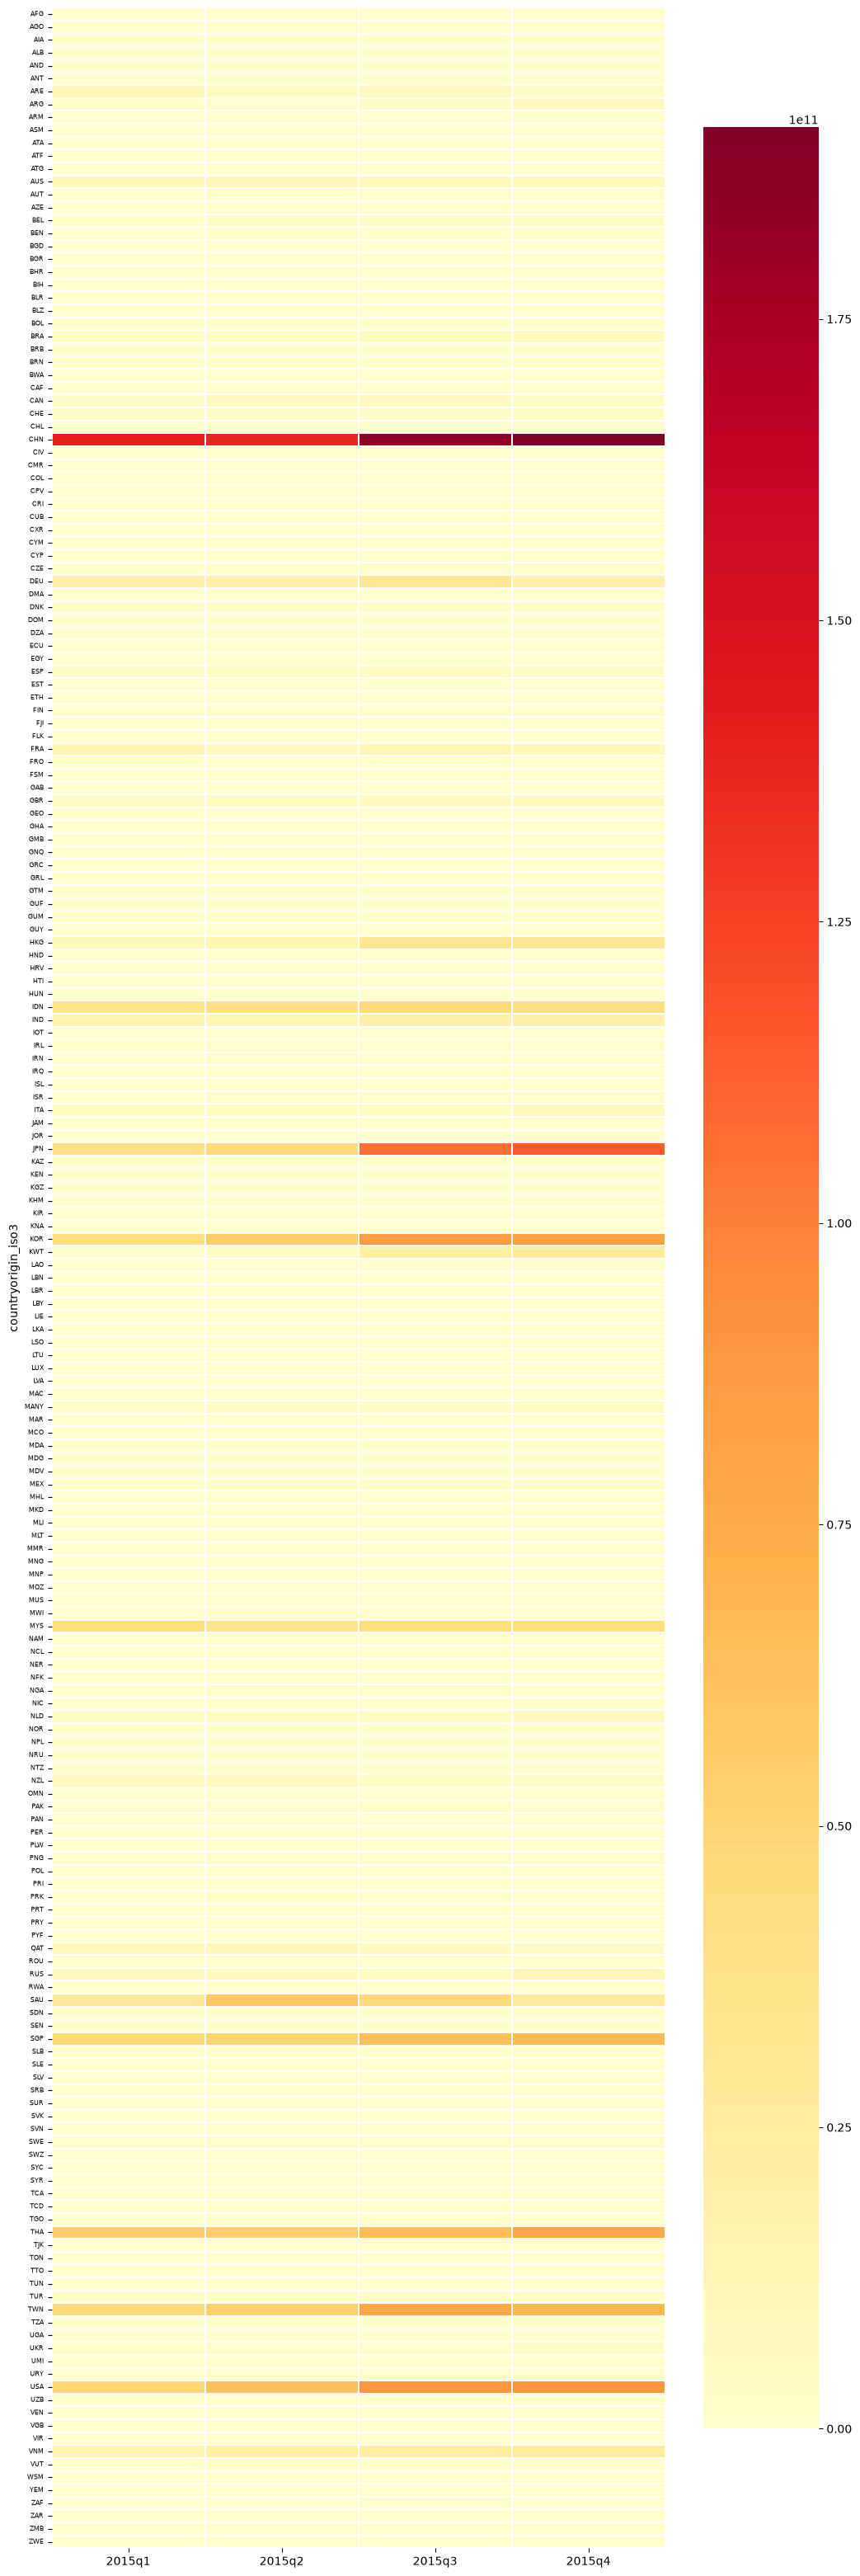

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 40))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.2,
    linecolor="white",
    ax=ax,
)

ax.set_yticks(np.arange(len(heatmap_data)) + 0.5)
ax.set_yticklabels(heatmap_data.index, fontsize=6)

print("Number of rows:", len(heatmap_data))
print("Number of tick positions:", len(ax.get_yticks()))
print("Number of tick labels:", len(ax.get_yticklabels()))
print("CHN label exists:", "CHN" in [label.get_text() for label in ax.get_yticklabels()])

plt.show()

In [28]:
print("CHN in data:", "CHN" in heatmap_data.index)
print("CHN position:", list(heatmap_data.index).index("CHN"))
print("Countries around CHN:")
print(heatmap_data.index[30:37].tolist())

CHN in data: True
CHN position: 33
Countries around CHN:
['CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COL']


In [29]:
import importlib
import src.plots

importlib.reload(src.plots)

print(src.plots.__file__)

c:\Users\Lance Santos\Downloads\case-study-2-git\src\plots.py


In [30]:
print("pivot exists:", "pivot" in globals())
print("heatmap_data exists:", "heatmap_data" in globals())

pivot exists: True
heatmap_data exists: True


In [31]:
from src.plots import make_bar_plot, make_heatmap

print("Plot functions loaded.")

Plot functions loaded.


In [32]:
import os
import sys

print(os.getcwd())
print(sys.path[0])

c:\Users\Lance Santos\Downloads\case-study-2-git
C:\Users\Lance Santos\AppData\Local\Programs\Python\Python313\python313.zip


In [33]:
import os

os.chdir(r"C:\Users\Lance Santos\Downloads\case-study-2-git")

print(os.getcwd())

C:\Users\Lance Santos\Downloads\case-study-2-git


In [34]:
import sys
import importlib

git_project = r"C:\Users\Lance Santos\Downloads\case-study-2-git"

# Put the Git project first
sys.path.insert(0, git_project)

# Remove the already-loaded old module
if "src.plots" in sys.modules:
    del sys.modules["src.plots"]

import src.plots

print(src.plots.__file__)

c:\Users\Lance Santos\Downloads\case-study-2-git\src\plots.py


In [35]:
import os

print("Current folder:", os.getcwd())
print("Git heatmap exists:", os.path.exists(
    r"C:\Users\Lance Santos\Downloads\case-study-2-git\heatmap.png"
))
print("Git heatmap modified:", os.path.getmtime(
    r"C:\Users\Lance Santos\Downloads\case-study-2-git\heatmap.png"
))

Current folder: C:\Users\Lance Santos\Downloads\case-study-2-git
Git heatmap exists: True
Git heatmap modified: 1790253985.4568305


In [36]:
import importlib
import src.plots

importlib.reload(src.plots)

print(src.plots.__file__)

c:\Users\Lance Santos\Downloads\case-study-2-git\src\plots.py


In [37]:
import os
import sys

os.chdir(r"C:\Users\Lance Santos\Downloads\case-study-2-git")

if r"C:\Users\Lance Santos\Downloads\case-study-2-git" not in sys.path:
    sys.path.insert(0, r"C:\Users\Lance Santos\Downloads\case-study-2-git")

import src.plots

print("Working directory:", os.getcwd())
print("plots.py:", src.plots.__file__)

Working directory: C:\Users\Lance Santos\Downloads\case-study-2-git
plots.py: c:\Users\Lance Santos\Downloads\case-study-2-git\src\plots.py


Heatmap shows the dutiable value for each country of origin across the four quarters of 2015